# 59 - Convolution from Scratch

**Section:** Convolution and transformations | **Prereqs:** `FNNs/ShiftedMNIST.ipynb` | **Next:** `Convolution and transformations/Conv2D_class.ipynb`

`FNNs/ScrambledMNIST.ipynb` proved a fully connected network ignores which pixels
are neighbours. Convolution is the fix, and this notebook builds it three ways -
by hand with two nested loops, with `scipy.signal.convolve2d`, and with
`torch.nn.functional.conv2d` - so the operation stops being a black box.

**What convolution is.** Slide a small matrix (the *kernel*) over the image. At
each position, multiply overlapping values and sum. The result is one number per
position, and the output is a map of 'how much does this kernel's pattern appear
here'.

**Why it fixes the FNN's blindness**
- **Local.** Each output depends only on a small neighbourhood, so adjacency is
  built into the operation.
- **Shared weights.** The *same* kernel is applied at every position, so a feature
  learned in one corner is recognised everywhere. That is translation invariance,
  and it is what `ShiftedMNIST.ipynb` showed an FNN lacks.
- **Cheap.** A 3x3 kernel is 9 parameters regardless of image size. The
  equivalent `Linear` layer on a 28x28 image needs 614,656.

**Convolution vs cross-correlation.** True convolution flips the kernel first;
PyTorch (and every deep learning framework) does not, so it is technically
cross-correlation. It makes no difference when the kernel is *learned* - the
model just learns the flipped version.

**The channel-format rule:** PyTorch wants `(batch, channels, height, width)`.
Getting an image into that shape is most of the work in the code below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from scipy.signal import convolve2d

from imageio.v2 import imread

## Manual 2-D Convolution

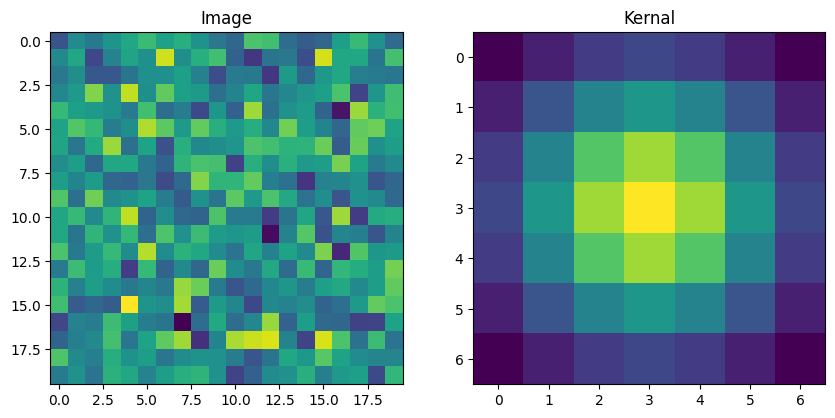

In [2]:
# A random 20x20 'image' and a 7x7 Gaussian kernel (bright in the middle,
# fading out). Convolving with it blurs - each output pixel becomes a weighted
# average of its neighbours.
imgN = 20
image = np.random.randn(imgN,imgN)

kernalN = 7
Y,X = np.meshgrid(np.linspace(-3,3,kernalN),np.linspace(-3,3,kernalN))
kernal = np.exp( -(X**2 + Y**2)/7) # Guassian Kernal

fig, ax = plt.subplots(1,2, figsize=(10,15))

ax[0].imshow(image)
ax[0].set_title("Image")


ax[1].imshow(kernal)
ax[1].set_title("Kernal");


## Gaussian (Normal Distribution)

The Gaussian (normal distribution) is defined as:

$$
f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)
$$

### Definitions

- **$f(x)$**  
  Probability density at value $x$.

- **$x$**  
  The variable or data point.

- **$\mu$ (mu)**  
  Mean of the distribution  
  Represents the center of the bell curve.

- **$\sigma$ (sigma)**  
  Standard deviation  
  Controls how wide or narrow the curve is.

- **$\sigma^2$**  
  Variance  
  Spread of the distribution.

- **$e$**  
  Euler’s number (~2.71828)  
  Base of natural logarithms.

- **$\exp(\cdot)$**  
  Exponential function  
  Equivalent to $e^{(\cdot)}$.

- **$\frac{1}{\sqrt{2\pi\sigma^2}}$**  
  Normalization constant  
  Ensures total probability integrates to 1.

---

## Simplified Gaussian (used in ML kernels)

Sometimes the normalization is removed:

$$
f(x) = e^{-\frac{(x - \mu)^2}{2\sigma^2}}
$$

Used in:
- RBF kernels
- Attention mechanisms
- Similarity functions

---

## Standard Normal Distribution

If $\mu = 0$ and $\sigma = 1$:

$$
f(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}
$$

This is called:
- Unit Gaussian
- Standard normal

---

## Multivariate Gaussian (Vector version)

$$
f(\mathbf{x}) =
\frac{1}{\sqrt{(2\pi)^k |\Sigma|}}
\exp\left(
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu})^T
\Sigma^{-1}
(\mathbf{x}-\boldsymbol{\mu})
\right)
$$

### Additional Definitions

- **$\mathbf{x}$**  
  Input vector

- **$k$**  
  Number of dimensions

- **$\boldsymbol{\mu}$**  
  Mean vector

- **$\Sigma$**  
  Covariance matrix  
  Encodes variance + feature correlations

- **$|\Sigma|$**  
  Determinant of covariance matrix

- **$\Sigma^{-1}$**  
  Inverse covariance (precision matrix)

---

## Log Gaussian (important for ML losses)

$$
\log f(x)
= -\frac{1}{2}\log(2\pi\sigma^2)
- \frac{(x-\mu)^2}{2\sigma^2}
$$

Why this matters:
- Leads to MSE loss
- Used in Gaussian likelihood
- Foundation of probabilistic regression

In [3]:
# Convolution by hand. For every valid centre position:
#   1. cut out the kernel-sized patch,
#   2. multiply elementwise by the kernel and sum.
# The [::-1,::-1] flips the kernel, which is what makes this true convolution
# rather than cross-correlation. Deep learning frameworks skip the flip, since a
# learned kernel can just as easily learn the flipped pattern.
# Note the loop starts at halfkr and stops early - hence the black border, and
# hence padding.
convoutput = np.zeros((imgN,imgN))
halfkr = kernalN//2

for rowi in range(halfkr,imgN-halfkr):
  for coli in range(halfkr,imgN-halfkr):

    pieceofImg = image[rowi-halfkr:rowi+halfkr+1,:]
    pieceofImg = pieceofImg[:,coli-halfkr:coli+halfkr+1]

    dotproduct = np.sum(pieceofImg*kernal[::-1,::-1]) # See the kernal is flipped, this is implemting convolution, in pytorch we don't do this...Model just learns the reverse.

    convoutput[rowi,coli] = dotproduct


In [4]:
# scipy's version. mode='valid' computes only the fully-overlapping positions,
# so the output is smaller than the input; mode='same' pads to keep the size.
scipy_output = convolve2d(image,kernal,mode='valid')

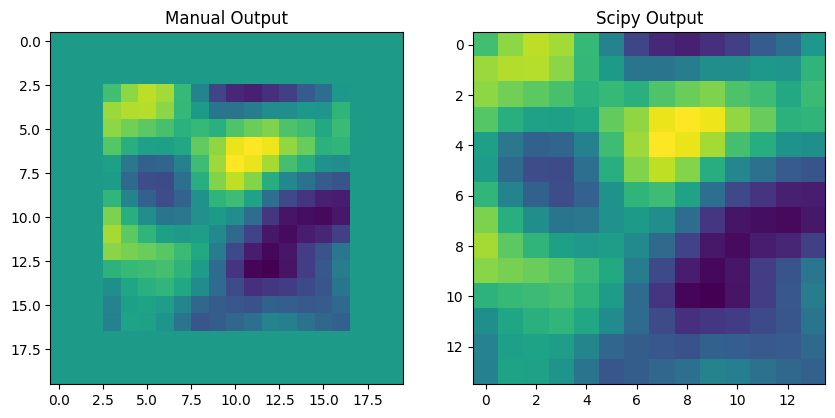

In [5]:
# The two results match - the loop above is really all convolution is.
fig, ax = plt.subplots(1,2, figsize=(10,15))

ax[0].imshow(convoutput)
ax[0].set_title("Manual Output")


ax[1].imshow(scipy_output)
ax[1].set_title("Scipy Output");


## Using acutal image

(750, 1200, 3)


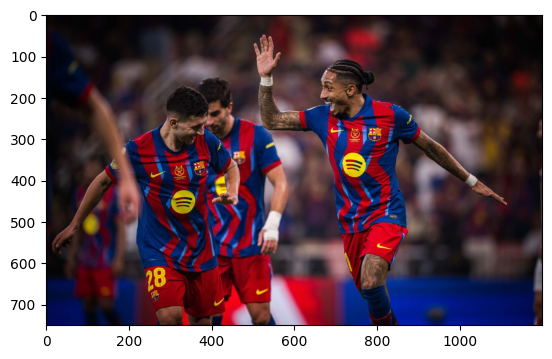

In [6]:
# A real photograph, averaged over its RGB channels to greyscale.
img = imread("https://www.fcbarcelona.com/photo-resources/2026/01/07/32b0d772-1c16-4b6e-a3b8-ae713b32b369/_MGA8022.jpg?width=1200&height=750")

print(img.shape)
plt.imshow(img);

img = np.mean(img, axis=2)
imp = img/np.max(img)

(750, 1200)


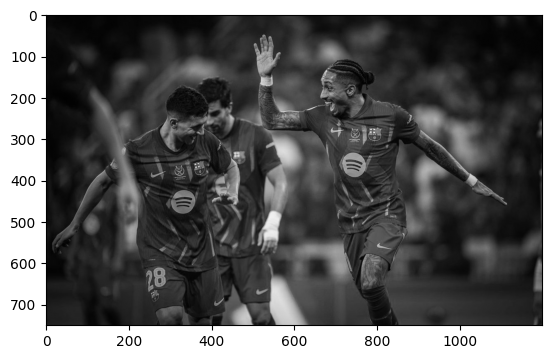

In [7]:
plt.imshow(img,cmap='grey');
print(img.shape)

In [8]:
# Two classic hand-designed edge detectors.
# VK has +1 on the left column and -1 on the right, so it responds where
# brightness changes horizontally: a VERTICAL edge. HK is its transpose and
# finds horizontal edges.
# The point: before deep learning these were designed by hand. A CNN LEARNS
# kernels like these in its first layer, which you can verify in
# CNNs/Examining_Feature_Maps.ipynb.
VK = np.array([[1,0,-1],
              [1,0,-1],
              [1,0,-1]])


HK = np.array([[1,1,1],
              [0,0,0],
              [-1,-1,-1]])

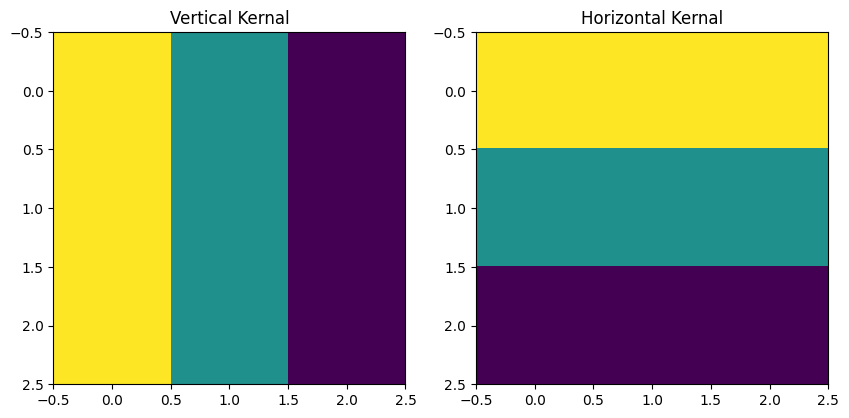

In [9]:
fig, ax = plt.subplots(1,2, figsize=(10,15))

ax[0].imshow(VK)
ax[0].set_title("Vertical Kernal")


ax[1].imshow(HK)
ax[1].set_title("Horizontal Kernal");

In [10]:
# Applying both. mode='same' pads so the output keeps the input's size.
V_output = convolve2d(img,VK,mode='same')
H_output = convolve2d(img, HK,mode='same')

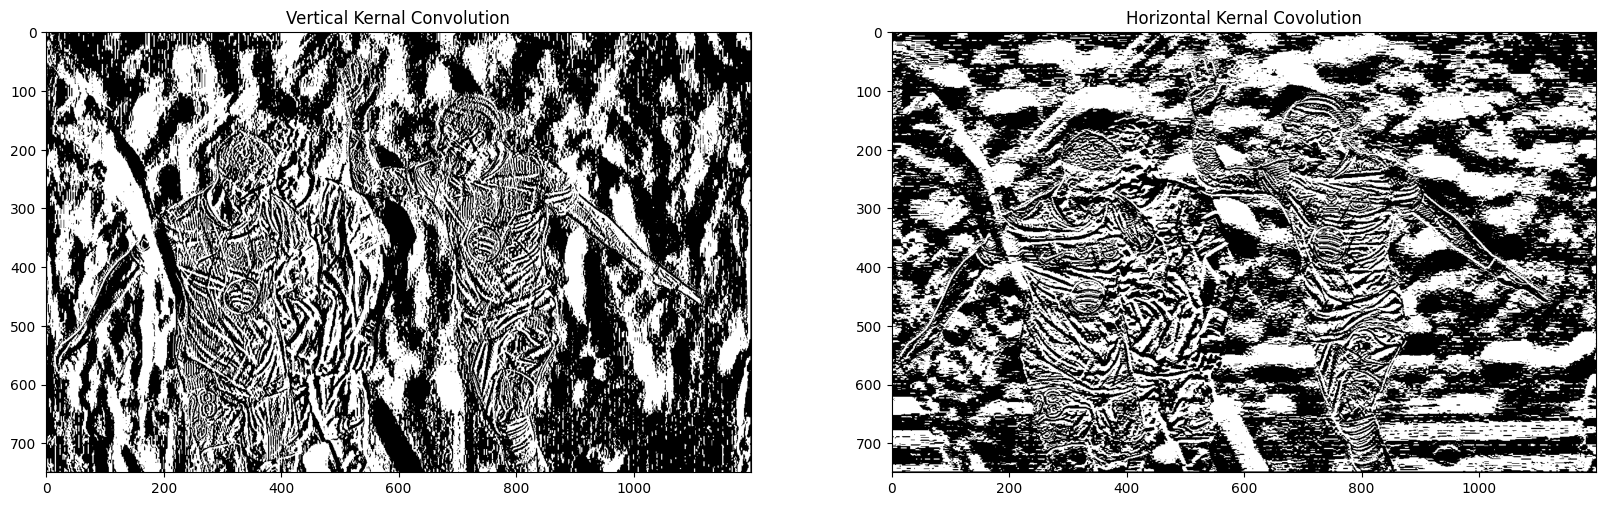

In [11]:
# The two edge maps. Vertical edges light up in one and horizontal in the other -
# from nothing but a 3x3 matrix of nine numbers.
fig, ax = plt.subplots(1,2, figsize=(20,30))

ax[0].imshow(V_output,cmap='grey',vmin=0,vmax=0.01)
ax[0].set_title("Vertical Kernal Convolution")


ax[1].imshow(H_output,cmap='grey',vmin=0,vmax=0.01)
ax[1].set_title("Horizontal Kernal Covolution");

## Convolution Using PyTorch

In [12]:
import torch
import torch.nn.functional as F

In [13]:
# The reshape every PyTorch vision operation needs:
#   (batch, channels, height, width)
# .view(1,1,3,3) turns a 3x3 kernel into 'one output channel, one input channel,
# 3x3'. Shape errors here are the most common beginner problem with conv layers.
VK = torch.tensor(VK).view(1,1,3,3).double()
HK = torch.tensor(HK).view(1,1,3,3).double()

img = torch.tensor(img).view(1,1, img.shape[0],img.shape[1]) # We do that because PyTorch is expecting the img and kernal in a format of (bs, channels, height, width)

In [18]:
img.shape

torch.Size([1, 1, 750, 1200])

In [19]:
# F.conv2d is the functional form (no learned parameters - you supply the
# kernel). nn.Conv2d is the layer version whose kernel is learned.
T_H_output = F.conv2d(img,HK)
T_V_output = F.conv2d(img, VK)

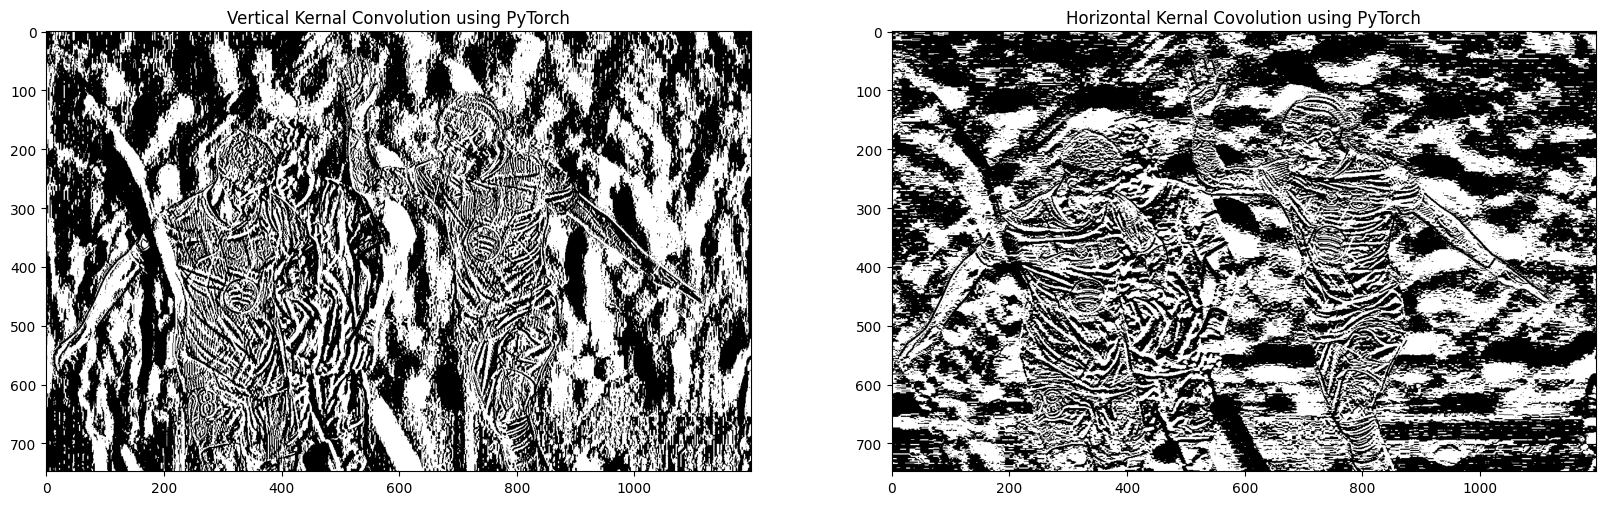

In [20]:
# Same edge maps as scipy produced. torch.squeeze drops the batch and channel
# axes of size 1 so matplotlib can plot a 2-D array.
fig, ax = plt.subplots(1,2, figsize=(20,30))

ax[0].imshow(torch.squeeze(T_V_output.detach()),cmap='grey',vmin=0,vmax=0.01)
ax[0].set_title("Vertical Kernal Convolution using PyTorch")


ax[1].imshow(torch.squeeze(T_H_output.detach()),cmap='grey',vmin=0,vmax=0.01)
ax[1].set_title("Horizontal Kernal Covolution using PyTorch");

In [21]:
torch.squeeze(T_H_output.detach()).shape, T_H_output.shape

(torch.Size([748, 1198]), torch.Size([1, 1, 748, 1198]))

### `torch.squeeze()` Explanation

`torch.squeeze()` is a PyTorch function used to remove dimensions of size 1 from a tensor.

*   When called without the `dim` argument, it removes **all** dimensions that have a size of 1.
*   When called with a specific `dim` argument (e.g., `torch.squeeze(tensor, dim=0)`), it only removes the dimension at that specified index if its size is 1. If the specified dimension's size is not 1, the tensor remains unchanged.

This function is useful for reducing the dimensionality of tensors when singleton dimensions are not semantically meaningful for subsequent operations, such as for plotting or certain model layers.

In [17]:
# squeeze() with no argument removes EVERY size-1 axis; with dim=i it removes
# only that one, and only if it is size 1.
# The counterpart is unsqueeze(dim), which ADDS a size-1 axis - the usual way to
# turn a single sample into a batch of one.
tensor_with_singletons = torch.randn(1, 10, 1, 20, 1)
print(f"Original tensor shape: {tensor_with_singletons.shape}")

squeezed_tensor = torch.squeeze(tensor_with_singletons)
print(f"Squeezed tensor shape (all dimensions of size 1 removed): {squeezed_tensor.shape}")

squeezed_dim_0 = torch.squeeze(tensor_with_singletons, dim=0)
print(f"Squeezed tensor shape (only dim 0 removed): {squeezed_dim_0.shape}")

squeezed_dim_2 = torch.squeeze(tensor_with_singletons, dim=2)
print(f"Squeezed tensor shape (only dim 2 removed): {squeezed_dim_2.shape}")

Original tensor shape: torch.Size([1, 10, 1, 20, 1])
Squeezed tensor shape (all dimensions of size 1 removed): torch.Size([10, 20])
Squeezed tensor shape (only dim 0 removed): torch.Size([10, 1, 20, 1])
Squeezed tensor shape (only dim 2 removed): torch.Size([1, 10, 20, 1])
